# Figure S17

Top: 1x3 scanner-manufacturer scatter panels with marginals, black best-fit line, and black 95% CI shading.

Bottom: SHAP summary plot for the final pooled model with human-readable feature names.


In [95]:
import glob
import json
import os
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_context('notebook')

config_candidates = [
    os.environ.get('CONFIG_PATH', ''),
    'config.json',
    '../config.json',
    '../../config.json',
    '../../../config.json',
]
config_path = next(
    (Path(p).expanduser().resolve() for p in config_candidates if p and Path(p).expanduser().exists()),
    None,
)
if config_path is None:
    raise FileNotFoundError('Could not find config.json. Set CONFIG_PATH or run from the project tree.')

config = json.loads(config_path.read_text())
project_root = Path(config['project_root']).expanduser().resolve()

raw_path = project_root / 'data' / 'raw_data' / 'merged_data_meisler_analyses.parquet'
cv_dir = project_root / 'data' / 'quality_classifier' / 'cross_validation_results'
model_path = project_root / 'data' / 'quality_classifier' / 'final_pooled_model' / 'final_model_all.joblib'

figure_dir = project_root / 'figures' / 'Supplement' / 'FigureS17'
panel_dir = figure_dir / 'panels'
panel_dir.mkdir(parents=True, exist_ok=True)

SCANNER_COLORS = {
    'Siemens': '#0077BB',
    'GE': '#EE7733',
    'Philips': '#009988',
}
vendor_order = ['Siemens', 'GE', 'Philips']

print(f'Using config: {config_path}')
print(f'Output dir: {figure_dir}')


Using config: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/config.json
Output dir: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17


<>:110: SyntaxWarning: invalid escape sequence '\i'
<>:110: SyntaxWarning: invalid escape sequence '\i'
/var/folders/4y/s6znprj1145dyy5j_hph01gm0000gn/T/ipykernel_99583/1359955041.py:110: SyntaxWarning: invalid escape sequence '\i'
  annot = f'$\it{{r}}$ = {r:.2f}\n95% CI [{lo:.2f}, {hi:.2f}]'
/var/folders/4y/s6znprj1145dyy5j_hph01gm0000gn/T/ipykernel_99583/1359955041.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_top_scatter_marginals_by_vendor_stacked.pdf
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_top_scatter_marginals_by_vendor_stacked.png


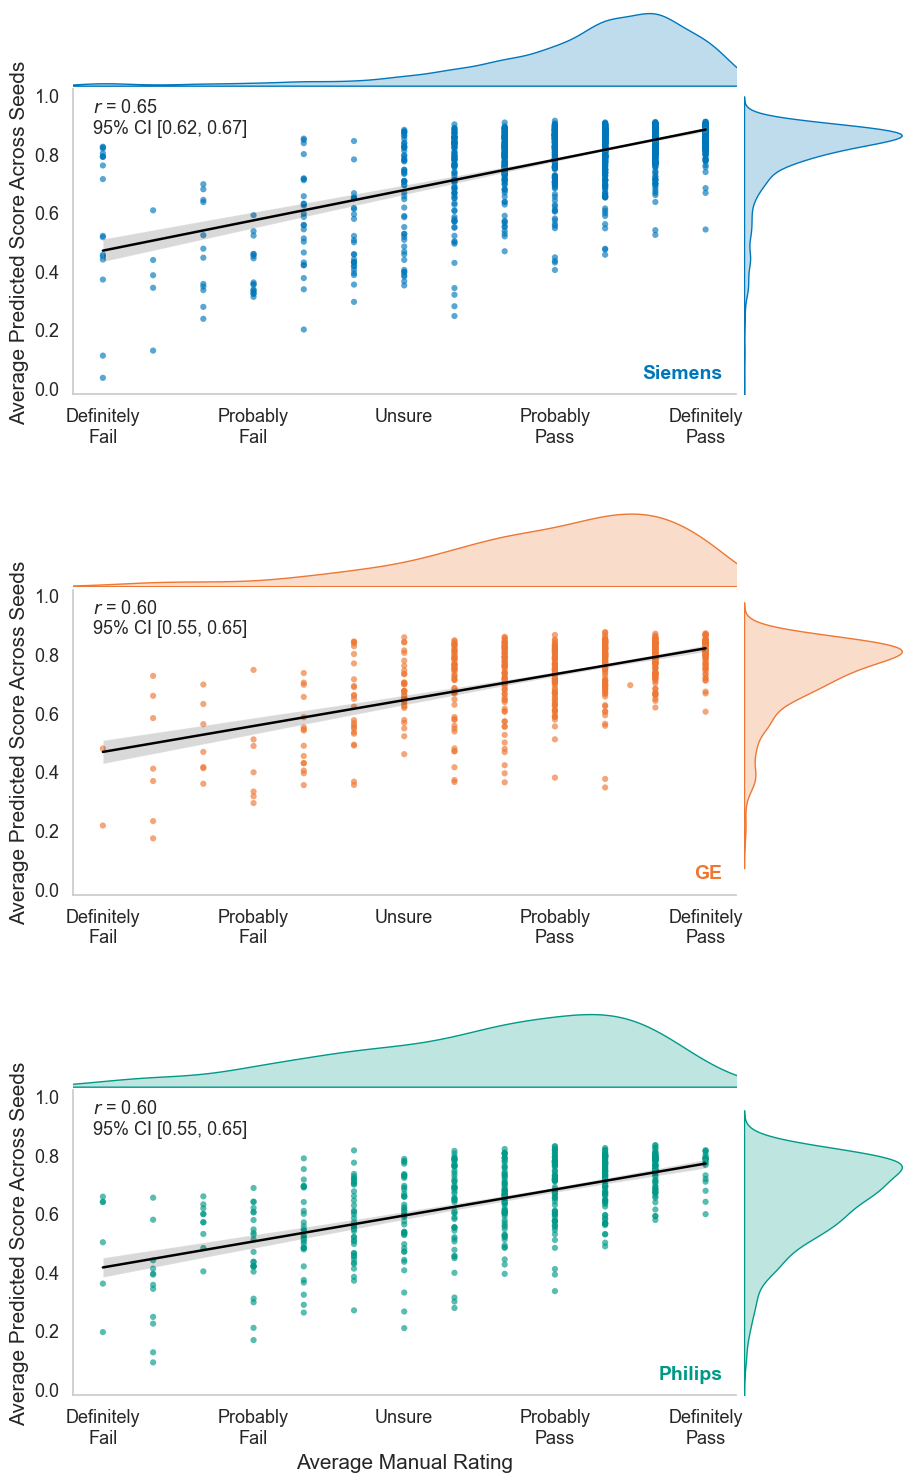

In [96]:
# Top panel: stacked vendor scatter + marginals (vertical)
df = pd.read_parquet(raw_path)

if 'scanner_manufacturer' not in df.columns and 'Manufacturer' in df.columns:
    df['scanner_manufacturer'] = df['Manufacturer']

if 'mean_rating' not in df.columns:
    if 'mean_rating_scaled' not in df.columns:
        raise ValueError('Need mean_rating or mean_rating_scaled in merged data.')
    df['mean_rating'] = pd.to_numeric(df['mean_rating_scaled'], errors='coerce') * 4.0 - 2.0
else:
    df['mean_rating'] = pd.to_numeric(df['mean_rating'], errors='coerce')

df = df.dropna(subset=['subject_session', 'scanner_manufacturer', 'mean_rating']).copy()

def normalize_vendor(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if 'siemens' in s:
        return 'Siemens'
    if 'philips' in s:
        return 'Philips'
    if s.startswith('ge') or 'general electric' in s:
        return 'GE'
    return np.nan

df['scanner_manufacturer'] = df['scanner_manufacturer'].map(normalize_vendor)
df = df[df['scanner_manufacturer'].isin(vendor_order)].copy()

manual_mean = (
    df.groupby(['subject_session', 'scanner_manufacturer'], as_index=False)['mean_rating']
    .mean()
    .rename(columns={'mean_rating': 'avg_manual_rating'})
)

cv_files = sorted(glob.glob(str(cv_dir / 'preds_ALL_*.csv')))
if not cv_files:
    raise FileNotFoundError(f'No prediction files found in {cv_dir} (expected preds_ALL_*.csv).')

cv_raw = pd.concat((pd.read_csv(f) for f in cv_files), ignore_index=True)
id_col = 'subject_session' if 'subject_session' in cv_raw.columns else 'id'
if id_col not in cv_raw.columns or 'y_pred_cont' not in cv_raw.columns:
    raise ValueError('CV files must include subject_session (or id) and y_pred_cont.')

pred_mean = (
    cv_raw.groupby(id_col, as_index=False)['y_pred_cont']
    .mean()
    .rename(columns={id_col: 'subject_session', 'y_pred_cont': 'avg_pred_score'})
)

plot_df = manual_mean.merge(pred_mean, on='subject_session', how='inner')
plot_df = plot_df.dropna(subset=['avg_manual_rating', 'avg_pred_score', 'scanner_manufacturer']).copy()

def pearson_ci(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    if n < 4:
        return np.nan, np.nan, np.nan
    r, _ = pearsonr(x, y)
    z = np.arctanh(np.clip(r, -0.999999, 0.999999))
    se = 1 / np.sqrt(n - 3)
    z_crit = 1.959963984540054
    lo = np.tanh(z - z_crit * se)
    hi = np.tanh(z + z_crit * se)
    return r, lo, hi

def style_axis_no_grid(ax):
    ax.grid(False)
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(10.8, 18.0), constrained_layout=False)
outer = fig.add_gridspec(nrows=3, ncols=1, hspace=0.30)

rating_ticks = [-2, -1, 0, 1, 2]
rating_labels = ['Definitely\nFail', 'Probably\nFail', 'Unsure', 'Probably\nPass', 'Definitely\nPass']

for i, vendor in enumerate(vendor_order):
    d = plot_df[plot_df['scanner_manufacturer'] == vendor].copy()
    g = outer[i].subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.02, wspace=0.02)
    ax_top = fig.add_subplot(g[0, 0])
    ax_main = fig.add_subplot(g[1, 0])
    ax_right = fig.add_subplot(g[1, 1])

    ax_main.scatter(
        d['avg_manual_rating'],
        d['avg_pred_score'],
        s=20,
        alpha=0.65,
        color=SCANNER_COLORS[vendor],
        edgecolors='none',
    )

    if len(d) >= 3:
        sns.regplot(
            data=d,
            x='avg_manual_rating',
            y='avg_pred_score',
            scatter=False,
            ci=95,
            color='black',
            line_kws={'lw': 1.8},
            ax=ax_main,
        )
        r, lo, hi = pearson_ci(d['avg_manual_rating'], d['avg_pred_score'])
        if np.isfinite(r):
            annot = f'$\it{{r}}$ = {r:.2f}\n95% CI [{lo:.2f}, {hi:.2f}]'
        else:
            annot = f'n = {len(d)}'
        ax_main.text(0.03, 0.97, annot, transform=ax_main.transAxes, va='top', ha='left', fontsize=13)

    sns.kdeplot(x=d['avg_manual_rating'], ax=ax_top, fill=True, alpha=0.25, lw=1.0, color=SCANNER_COLORS[vendor])
    sns.kdeplot(y=d['avg_pred_score'], ax=ax_right, fill=True, alpha=0.25, lw=1.0, color=SCANNER_COLORS[vendor])

    ax_main.text(0.98, 0.04, vendor, transform=ax_main.transAxes, va='bottom', ha='right',
                 fontsize=14, fontweight='bold', color=SCANNER_COLORS[vendor])

    ax_main.set_ylim(-0.02, 1.02)
    ax_main.set_xticks(rating_ticks)
    ax_main.set_xticklabels(rating_labels, fontsize=13)
    if i == len(vendor_order) - 1:
        ax_main.set_xlabel('Average Manual Rating', fontsize=15)
    else:
        ax_main.set_xlabel('')
    ax_main.set_ylabel('Average Predicted Score Across Seeds', fontsize=15)
    ax_main.tick_params(axis='y', labelsize=13)

    for ax in [ax_top, ax_main, ax_right]:
        style_axis_no_grid(ax)

    ax_top.set_xlim(ax_main.get_xlim())

    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_xlabel('')
    ax_top.set_ylabel('')

    ax_right.set_ylim(-0.02, 1.02)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.set_xlabel('')
    ax_right.set_ylabel('')

    for ax_m in [ax_top, ax_right]:
        ax_m.spines['left'].set_visible(False)
        ax_m.spines['bottom'].set_visible(False)

fig.tight_layout()

top_png = panel_dir / 'FigureS17_top_scatter_marginals_by_vendor_stacked.png'
top_pdf = panel_dir / 'FigureS17_top_scatter_marginals_by_vendor_stacked.pdf'
fig.savefig(top_png, dpi=300, bbox_inches='tight')
fig.savefig(top_pdf, bbox_inches='tight')
print(f'[SAVED] {top_pdf}')
print(f'[SAVED] {top_png}')
plt.show()


[INFO] SHAP x-limit set to (-0.150, 0.023)
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_bottom_shap_summary_human_readable.pdf
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_bottom_shap_summary_human_readable.png


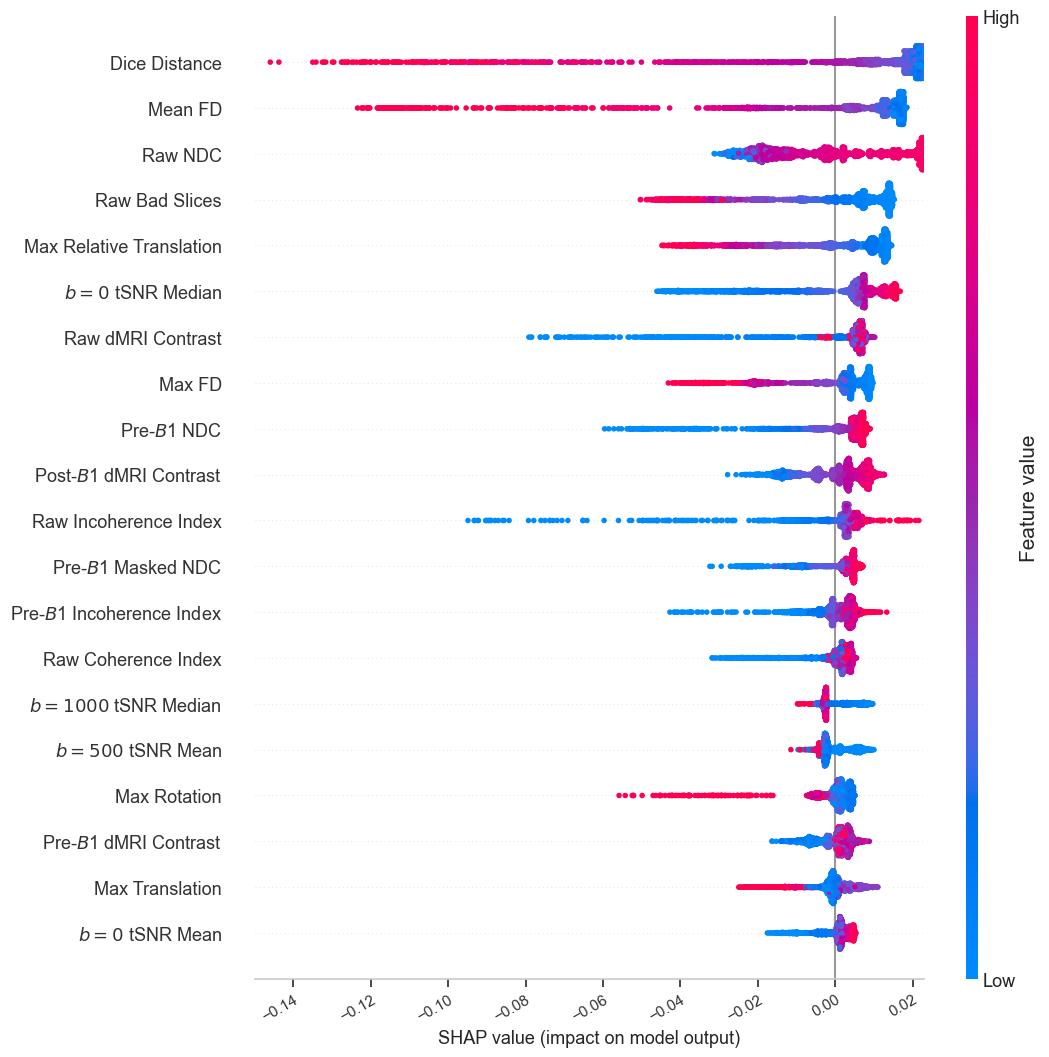

In [97]:
# Bottom panel: SHAP summary with cleaner human-readable feature labels
qc_module_dir = project_root / 'scripts' / 'quality_classifier' / 'automated_classification'
if str(qc_module_dir) not in sys.path:
    sys.path.insert(0, str(qc_module_dir))
from model_utils import FEATURE_COLUMNS  # noqa: E402

shap_df = df.copy()
shap_df = shap_df[shap_df['mean_rating'].notna()].copy()
for col in FEATURE_COLUMNS:
    shap_df[col] = pd.to_numeric(shap_df[col], errors='coerce')
shap_df = shap_df.dropna(subset=FEATURE_COLUMNS).copy()

X = shap_df[FEATURE_COLUMNS].copy()

def human_feature_name(col):
    if col == 't1_dice_distance':
        return 'Dice Distance'

    shell_map = {
        'CNR0': r'$b = 0$ tSNR',
        'CNR1': r'$b = 500$ tSNR',
        'CNR2': r'$b = 1000$ tSNR',
        'CNR3': r'$b = 2000$ tSNR',
        'CNR4': r'$b = 3000$ tSNR',
    }
    for shell, shell_label in shell_map.items():
        if col.startswith(shell + '_'):
            stat = col.split('_', 1)[1]
            stat_map = {'mean': 'Mean', 'median': 'Median', 'standard_deviation': 'SD'}
            return f"{shell_label} {stat_map.get(stat, stat)}"

    if col.startswith('t1post_'):
        prefix = r'Post-$B$1 '
        base = col.replace('t1post_', '')
    elif col.startswith('t1_'):
        prefix = r'Pre-$B$1 '
        base = col.replace('t1_', '')
    elif col.startswith('raw_'):
        prefix = 'Raw '
        base = col.replace('raw_', '')
    else:
        prefix = ''
        base = col

    replacements = [
        ('masked_neighbor_corr', 'Masked NDC'),
        ('neighbor_corr', 'NDC'),
        ('incoherence_index', 'Incoherence Index'),
        ('coherence_index', 'Coherence Index'),
        ('dwi_contrast', 'dMRI Contrast'),
        ('num_bad_slices', 'Bad Slices'),
        ('mean_fd', 'Mean FD'),
        ('max_fd', 'Max FD'),
        ('max_rotation', 'Max Rotation'),
        ('max_translation', 'Max Translation'),
        ('max_rel_rotation', 'Max Relative Rotation'),
        ('max_rel_translation', 'Max Relative Translation'),
        ('standard_deviation', 'SD'),
    ]
    for old, new in replacements:
        base = base.replace(old, new)

    base = base.replace('_', ' ').strip()
    return f'{prefix}{base}'.strip()

X_human = X.copy()
X_human.columns = [human_feature_name(c) for c in X.columns]

model = joblib.load(model_path)
explainer = shap.TreeExplainer(model)

plt.figure(figsize=(10.8, 12.5))
shap_matrix = None
try:
    shap_exp = explainer(X_human)
    shap_matrix = np.asarray(shap_exp.values)
    shap.plots.beeswarm(shap_exp, max_display=20, show=False, plot_size=None, group_remaining_features=False)
except Exception:
    shap_vals = explainer.shap_values(X_human)
    shap_matrix = np.asarray(shap_vals)
    shap_exp = shap.Explanation(values=shap_matrix, data=X_human.values, feature_names=list(X_human.columns))
    shap.plots.beeswarm(shap_exp, max_display=20, show=False, plot_size=None, group_remaining_features=False)

fig = plt.gcf()
shap_axes = [
    ax for ax in fig.axes
    if isinstance(ax.get_xlabel(), str) and 'shap value' in ax.get_xlabel().lower()
]
if len(shap_axes) == 0:
    shap_axes = sorted(fig.axes, key=lambda a: len(a.collections) + len(a.lines), reverse=True)
ax_main = shap_axes[0]

upper = float(np.nanpercentile(shap_matrix, 99.5))
upper = min(0.10, max(0.02, upper))
ax_main.set_xlim(-0.15, upper)
ax_main.grid(False)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
plt.setp(ax_main.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')

print(f'[INFO] SHAP x-limit set to (-0.150, {upper:.3f})')

for ax_cb in fig.axes:
    if ax_cb is not ax_main and isinstance(ax_cb.get_ylabel(), str) and 'feature value' in ax_cb.get_ylabel().lower():
        ax_cb.set_ylabel(ax_cb.get_ylabel(), fontsize=15)
        ax_cb.tick_params(axis='y', labelsize=13)

shap_png = panel_dir / 'FigureS17_bottom_shap_summary_human_readable.png'
shap_pdf = panel_dir / 'FigureS17_bottom_shap_summary_human_readable.pdf'
plt.savefig(shap_png, dpi=300, bbox_inches='tight')
plt.savefig(shap_pdf, bbox_inches='tight')
print(f'[SAVED] {shap_pdf}')
print(f'[SAVED] {shap_png}')
plt.show()



[INFO] Combined SHAP x-limit set to (-0.150, 0.023)
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/FigureS17_combined_tall.pdf
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/FigureS17_combined_tall.png


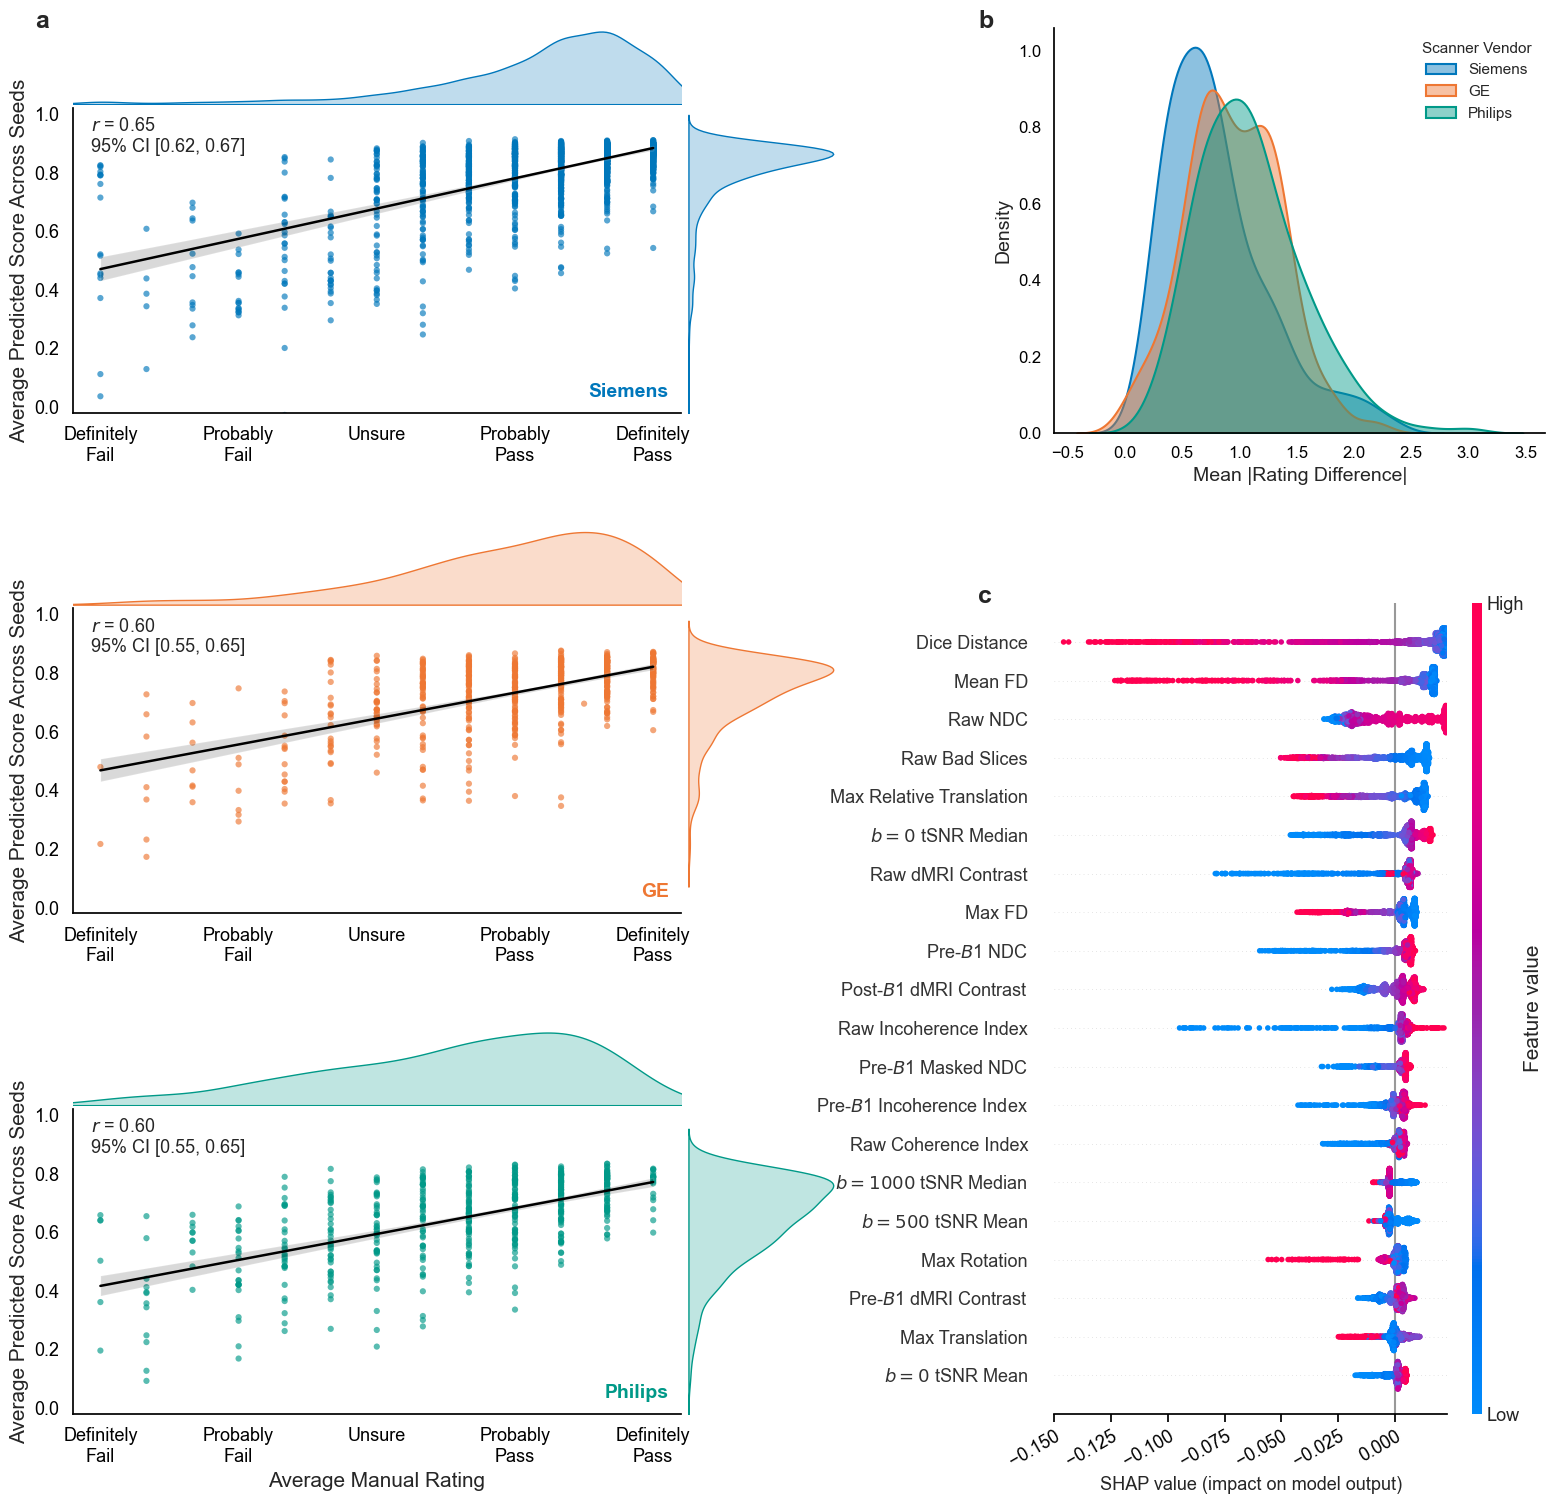

In [98]:
# Combined tall figure export (left: stacked scatters, right: top disagreement + shorter SHAP)
fig = plt.figure(figsize=(19, 18), constrained_layout=False)
gs = fig.add_gridspec(1, 2, width_ratios=[1.22, 0.78], wspace=0.34)
left_gs = gs[0, 0].subgridspec(3, 1, hspace=0.30)
right_gs = gs[0, 1].subgridspec(2, 1, height_ratios=[1.0, 2.0], hspace=0.28)

rating_ticks = [-2, -1, 0, 1, 2]
rating_labels = ['Definitely\nFail', 'Probably\nFail', 'Unsure', 'Probably\nPass', 'Definitely\nPass']

for i, vendor in enumerate(vendor_order):
    d = plot_df[plot_df['scanner_manufacturer'] == vendor].copy()
    g = left_gs[i].subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.02, wspace=0.02)
    ax_top = fig.add_subplot(g[0, 0])
    ax_main = fig.add_subplot(g[1, 0])
    ax_right = fig.add_subplot(g[1, 1])

    ax_main.scatter(
        d['avg_manual_rating'],
        d['avg_pred_score'],
        s=20,
        alpha=0.65,
        color=SCANNER_COLORS[vendor],
        edgecolors='none',
    )
    if len(d) >= 3:
        sns.regplot(
            data=d,
            x='avg_manual_rating',
            y='avg_pred_score',
            scatter=False,
            ci=95,
            color='black',
            line_kws={'lw': 1.8},
            ax=ax_main,
        )
        r, lo, hi = pearson_ci(d['avg_manual_rating'], d['avg_pred_score'])
        if np.isfinite(r):
            annot = f'$\\it{{r}}$ = {r:.2f}\n95% CI [{lo:.2f}, {hi:.2f}]'
        else:
            annot = f'n = {len(d)}'
        ax_main.text(0.03, 0.97, annot, transform=ax_main.transAxes, va='top', ha='left', fontsize=13)

    sns.kdeplot(x=d['avg_manual_rating'], ax=ax_top, fill=True, alpha=0.25, lw=1.0, color=SCANNER_COLORS[vendor])
    sns.kdeplot(y=d['avg_pred_score'], ax=ax_right, fill=True, alpha=0.25, lw=1.0, color=SCANNER_COLORS[vendor])

    ax_main.text(0.98, 0.04, vendor, transform=ax_main.transAxes, va='bottom', ha='right',
                 fontsize=14, fontweight='bold', color=SCANNER_COLORS[vendor])


    ax_main.set_ylim(-0.02, 1.02)
    ax_main.set_xticks(rating_ticks)
    ax_main.set_xticklabels(rating_labels, fontsize=13)
    if i == len(vendor_order) - 1:
        ax_main.set_xlabel('Average Manual Rating', fontsize=15)
    else:
        ax_main.set_xlabel('')
    ax_main.set_ylabel('Average Predicted Score Across Seeds', fontsize=15)
    ax_main.tick_params(axis='y', labelsize=13)

    for ax in [ax_top, ax_main, ax_right]:
        ax.grid(False)
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.tick_params(axis='both', colors='black')

    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_xlabel('')
    ax_top.set_ylabel('')

    ax_right.set_ylim(-0.02, 1.02)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.set_xlabel('')
    ax_right.set_ylabel('')

    for ax_m in [ax_top, ax_right]:
        ax_m.spines['left'].set_visible(False)
        ax_m.spines['bottom'].set_visible(False)

# Top-right: inter-rater disagreement KDE
ax_disagree = fig.add_subplot(right_gs[0, 0])

if 'df_disagree' in globals() and isinstance(df_disagree, pd.DataFrame) and {'vendor', 'avg_disagreement'}.issubset(df_disagree.columns):
    _df_disagree = df_disagree.copy()
else:
    import re
    ratings_candidates = [
        Path(os.environ.get('RATINGS_PATH', '')) if os.environ.get('RATINGS_PATH') else None,
        project_root / 'data' / 'manual_ratings' / 'final_ratings',
        project_root / 'data' / 'final_ratings',
        project_root / 'paper_code' / 'final_ratings',
        Path('/Users/stevenmeisler/Documents/Penn/abcc-qsiprep/paper_code/final_ratings'),
    ]
    ratings_candidates = [q for q in ratings_candidates if q is not None]
    ratings_path = next((q for q in ratings_candidates if q.exists()), None)
    if ratings_path is None:
        raise FileNotFoundError('Could not find final ratings directory. Set RATINGS_PATH.')

    expert_rows = []
    for f in sorted(ratings_path.glob('*.csv')):
        x = pd.read_csv(f)
        if not {'subject', 'rating'}.issubset(x.columns):
            continue
        token = f.name.lower()
        if token.startswith('ge'):
            vendor = 'GE'
        elif token.startswith('philips'):
            vendor = 'Philips'
        else:
            vendor = 'Siemens'
        m = re.search(r'(?<=rater_)\d+', f.name)
        rater_num = int(m.group(0)) if m else None
        x = x[['subject', 'rating']].copy()
        x['vendor'] = vendor
        x['filename'] = str(f)
        x['rater_num'] = rater_num
        expert_rows.append(x)

    expert_qc = pd.concat(expert_rows, ignore_index=True)
    siemens_files = sorted(expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'filename'].dropna().unique())
    siemens_codes = {fl: i + 1 for i, fl in enumerate(siemens_files)}
    expert_qc['rater'] = expert_qc['rater_num']
    expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'rater'] = expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'filename'].map(siemens_codes)

    expert_qc['subject'] = expert_qc['subject'].astype(str)
    expert_qc['subject'] = expert_qc['subject'].str.replace('NDARINV', '', regex=False)
    expert_qc['subject'] = expert_qc['subject'].str.replace('ses-baselineYear1Arm1', 'ses-00A', regex=False)
    expert_qc['subject'] = expert_qc['subject'].str.replace('ses-2YearFollowUpYArm1', 'ses-02A', regex=False)
    expert_qc['rating'] = pd.to_numeric(expert_qc['rating'], errors='coerce')
    expert_qc = expert_qc.dropna(subset=['subject', 'rating', 'vendor', 'rater']).copy()
    expert_qc['rater'] = expert_qc['rater'].astype(int)

    def avg_disagreement_matrix(df_vendor):
        wide = (
            df_vendor[['subject', 'rater', 'rating']]
            .pivot_table(index='subject', columns='rater', values='rating', aggfunc='mean')
        )
        raters = sorted(wide.columns.astype(int).tolist())
        n = len(raters)
        if n < 2:
            return pd.DataFrame(index=raters, columns=raters, dtype=float)

        total = np.zeros((n, n), dtype=float)
        shared = np.zeros((n, n), dtype=float)
        for ii in range(n - 1):
            for jj in range(ii + 1, n):
                r1, r2 = raters[ii], raters[jj]
                pair_df = wide[[r1, r2]].dropna()
                if len(pair_df) == 0:
                    continue
                d = np.abs(pair_df[r1].to_numpy(dtype=float) - pair_df[r2].to_numpy(dtype=float))
                total[ii, jj] = total[jj, ii] = np.sum(d)
                shared[ii, jj] = shared[jj, ii] = len(pair_df)

        with np.errstate(invalid='ignore', divide='ignore'):
            avg = total / shared
        avg[shared == 0] = np.nan
        return pd.DataFrame(avg, index=raters, columns=raters)

    _frames = []
    for vendor in vendor_order:
        mat = avg_disagreement_matrix(expert_qc[expert_qc['vendor'] == vendor].copy()).to_numpy(dtype=float)
        if mat.size == 0:
            continue
        tri = mat[np.triu_indices_from(mat, k=1)]
        tri = tri[np.isfinite(tri)]
        _frames.append(pd.DataFrame({'avg_disagreement': tri, 'vendor': vendor}))

    _df_disagree = pd.concat(_frames, ignore_index=True)

for vendor in vendor_order:
    dv = _df_disagree[_df_disagree['vendor'] == vendor]
    if len(dv) == 0:
        continue
    sns.kdeplot(
        data=dv,
        x='avg_disagreement',
        ax=ax_disagree,
        fill=True,
        alpha=0.45,
        lw=1.5,
        color=SCANNER_COLORS[vendor],
        label=vendor,
    )

ax_disagree.set_xlabel('Mean |Rating Difference|', fontsize=14)
ax_disagree.set_ylabel('Density', fontsize=14)
ax_disagree.tick_params(axis='both', labelsize=12, colors='black')
ax_disagree.grid(False)
ax_disagree.spines['top'].set_visible(False)
ax_disagree.spines['right'].set_visible(False)
ax_disagree.spines['left'].set_color('black')
ax_disagree.spines['bottom'].set_color('black')
ax_disagree.legend(frameon=False, title='Scanner Vendor', fontsize=11, title_fontsize=11)

# Bottom-right: SHAP (shorter panel; font size/width unchanged)
ax_shap = fig.add_subplot(right_gs[1, 0])
pos_shap = ax_shap.get_position()
ax_shap.set_position([pos_shap.x0 + 0.035, pos_shap.y0, pos_shap.width - 0.035, pos_shap.height])
model = joblib.load(model_path)
explainer = shap.TreeExplainer(model)

try:
    shap_exp_comb = explainer(X_human)
    shap_mat_comb = np.asarray(shap_exp_comb.values)
except Exception:
    shap_vals_comb = explainer.shap_values(X_human)
    shap_mat_comb = np.asarray(shap_vals_comb)
    shap_exp_comb = shap.Explanation(values=shap_mat_comb, data=X_human.values, feature_names=list(X_human.columns))

shap.plots.beeswarm(shap_exp_comb, max_display=20, show=False, plot_size=None, ax=ax_shap, group_remaining_features=False)

upper = float(np.nanpercentile(shap_mat_comb, 99.5))
upper = min(0.08, max(0.02, upper))
ax_shap.set_xlim(-0.15, upper)
ax_shap.tick_params(axis='y', labelsize=13, pad=-1)
ax_shap.tick_params(axis='x', labelsize=13, colors='black')
plt.setp(ax_shap.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor')
ax_shap.grid(False)
ax_shap.spines['top'].set_visible(False)
ax_shap.spines['right'].set_visible(False)
ax_shap.spines['left'].set_color('black')
ax_shap.spines['bottom'].set_color('black')

# Figure-level panel letters for exact visual alignment
pos_a = left_gs[0].get_position(fig)
pos_b = ax_disagree.get_position()
pos_c = ax_shap.get_position()
label_y_top = pos_b.y1 + 0.01
fig.text(pos_a.x0 - 0.02, label_y_top, 'a', fontsize=18, fontweight='bold', ha='left', va='top')
fig.text(pos_b.x0 - 0.04, label_y_top, 'b', fontsize=18, fontweight='bold', ha='left', va='top')
fig.text(pos_c.x0 - 0.04, pos_c.y1 + 0.01, 'c', fontsize=18, fontweight='bold', ha='left', va='top')

print(f'[INFO] Combined SHAP x-limit set to (-0.150, {upper:.3f})')

for ax_cb in fig.axes:
    if ax_cb is not ax_shap and isinstance(ax_cb.get_ylabel(), str) and 'feature value' in ax_cb.get_ylabel().lower():
        ax_cb.set_ylabel(ax_cb.get_ylabel(), fontsize=15)
        ax_cb.tick_params(axis='y', labelsize=13)

combined_png = figure_dir / 'FigureS17_combined_tall.png'
combined_pdf = figure_dir / 'FigureS17_combined_tall.pdf'
fig.savefig(combined_png, dpi=300, bbox_inches='tight', pad_inches=0.02)
fig.savefig(combined_pdf, bbox_inches='tight', pad_inches=0.02)
print(f'[SAVED] {combined_pdf}')
print(f'[SAVED] {combined_png}')
plt.show()










[INFO] Ratings source: /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/data/quality_classifier/final_ratings
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_interrater_disagreement_kde.pdf
[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Supplement/FigureS17/panels/FigureS17_interrater_disagreement_kde.png
         count      mean       std
vendor                            
GE       210.0  0.948964  0.408044
Philips  210.0  1.088246  0.463105
Siemens  253.0  0.806804  0.456294


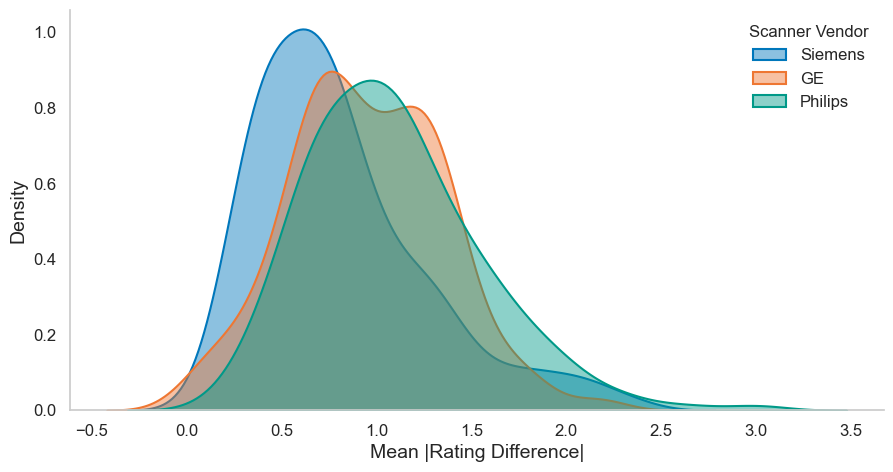

In [99]:
# Standalone panel: inter-rater disagreement KDE by scanner manufacturer
from itertools import combinations

# Match Fig2.Rmd source/logic: read expert rating CSV files and compute
# average pairwise disagreement per rater pair within each vendor.
ratings_candidates = [
    Path(os.environ.get('RATINGS_PATH', '')) if os.environ.get('RATINGS_PATH') else None,
    project_root / 'data' / 'quality_classifier' / 'final_ratings'
]
ratings_candidates = [p for p in ratings_candidates if p is not None]
ratings_path = next((p for p in ratings_candidates if p.exists()), None)
if ratings_path is None:
    raise FileNotFoundError(
        'Could not find final ratings directory. Set RATINGS_PATH or place files in one of: '        + ', '.join(str(p) for p in ratings_candidates)
    )

rating_files = sorted(ratings_path.glob('*.csv'))
if not rating_files:
    raise FileNotFoundError(f'No rating CSVs found in {ratings_path}')

expert_rows = []
for f in rating_files:
    x = pd.read_csv(f)
    if not {'subject', 'rating'}.issubset(x.columns):
        continue

    file_token = f.name
    token_lower = file_token.lower()
    if token_lower.startswith('ge'):
        vendor = 'GE'
    elif token_lower.startswith('philips'):
        vendor = 'Philips'
    else:
        vendor = 'Siemens'

    m = None
    import re
    m = re.search(r'(?<=rater_)\d+', file_token)
    rater_num = int(m.group(0)) if m else None

    x = x[['subject', 'rating']].copy()
    x['vendor'] = vendor
    x['filename'] = str(f)
    x['rater_num'] = rater_num
    expert_rows.append(x)

if not expert_rows:
    raise ValueError(f'No usable rating files in {ratings_path}; each file needs subject and rating columns.')

expert_qc = pd.concat(expert_rows, ignore_index=True)

# GE/Philips use rater_num from filename. Siemens gets one ID per file.
siemens_file_codes = {f: i + 1 for i, f in enumerate(sorted(expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'filename'].dropna().unique()))}
expert_qc['rater'] = expert_qc['rater_num']
expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'rater'] = expert_qc.loc[expert_qc['vendor'] == 'Siemens', 'filename'].map(siemens_file_codes)

# Subject cleaning to match Fig2.Rmd
expert_qc['subject'] = expert_qc['subject'].astype(str)
expert_qc['subject'] = expert_qc['subject'].str.replace('NDARINV', '', regex=False)
expert_qc['subject'] = expert_qc['subject'].str.replace('ses-baselineYear1Arm1', 'ses-00A', regex=False)
expert_qc['subject'] = expert_qc['subject'].str.replace('ses-2YearFollowUpYArm1', 'ses-02A', regex=False)
expert_qc['rating'] = pd.to_numeric(expert_qc['rating'], errors='coerce')
expert_qc = expert_qc.dropna(subset=['subject', 'rating', 'vendor', 'rater']).copy()
expert_qc['rater'] = expert_qc['rater'].astype(int)

def avg_disagreement_matrix(df_vendor):
    # wide table: one row per subject, one column per rater
    wide = (
        df_vendor[['subject', 'rater', 'rating']]
        .dropna(subset=['rater'])
        .pivot_table(index='subject', columns='rater', values='rating', aggfunc='mean')
    )
    raters = sorted(wide.columns.astype(int).tolist())
    n = len(raters)
    if n < 2:
        return pd.DataFrame(index=raters, columns=raters, dtype=float)

    total = np.zeros((n, n), dtype=float)
    shared = np.zeros((n, n), dtype=float)

    for i in range(n - 1):
        for j in range(i + 1, n):
            r1, r2 = raters[i], raters[j]
            pair_df = wide[[r1, r2]].dropna()
            if len(pair_df) == 0:
                continue
            d = np.abs(pair_df[r1].to_numpy(dtype=float) - pair_df[r2].to_numpy(dtype=float))
            total[i, j] = total[j, i] = np.sum(d)
            shared[i, j] = shared[j, i] = len(pair_df)

    with np.errstate(invalid='ignore', divide='ignore'):
        avg = total / shared
    avg[shared == 0] = np.nan
    return pd.DataFrame(avg, index=raters, columns=raters)

def upper_triangle_vals(mat_df, vendor_name):
    vals = mat_df.to_numpy(dtype=float)
    tri = vals[np.triu_indices_from(vals, k=1)]
    tri = tri[np.isfinite(tri)]
    return pd.DataFrame({'avg_disagreement': tri, 'vendor': vendor_name})

vendor_mats = {}
for vendor in vendor_order:
    dsub = expert_qc[expert_qc['vendor'] == vendor].copy()
    vendor_mats[vendor] = avg_disagreement_matrix(dsub)

df_disagree = pd.concat(
    [upper_triangle_vals(vendor_mats[v], v) for v in vendor_order if vendor_mats[v].size > 0],
    ignore_index=True
)
if df_disagree.empty:
    raise ValueError('No pairwise disagreement values were computed.')

fig, ax = plt.subplots(figsize=(10.5, 5.2))
for vendor in vendor_order:
    dv = df_disagree[df_disagree['vendor'] == vendor]
    if len(dv) == 0:
        continue
    sns.kdeplot(
        data=dv,
        x='avg_disagreement',
        ax=ax,
        fill=True,
        alpha=0.45,
        lw=1.5,
        color=SCANNER_COLORS[vendor],
        label=vendor,
    )

ax.set_xlabel('Mean |Rating Difference|', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, title='Scanner Vendor', fontsize=12, title_fontsize=12)

out_png = panel_dir / 'FigureS17_interrater_disagreement_kde.png'
out_pdf = panel_dir / 'FigureS17_interrater_disagreement_kde.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f'[INFO] Ratings source: {ratings_path}')
print(f'[SAVED] {out_pdf}')
print(f'[SAVED] {out_png}')
print(df_disagree.groupby('vendor')['avg_disagreement'].describe()[['count', 'mean', 'std']])
plt.show()
